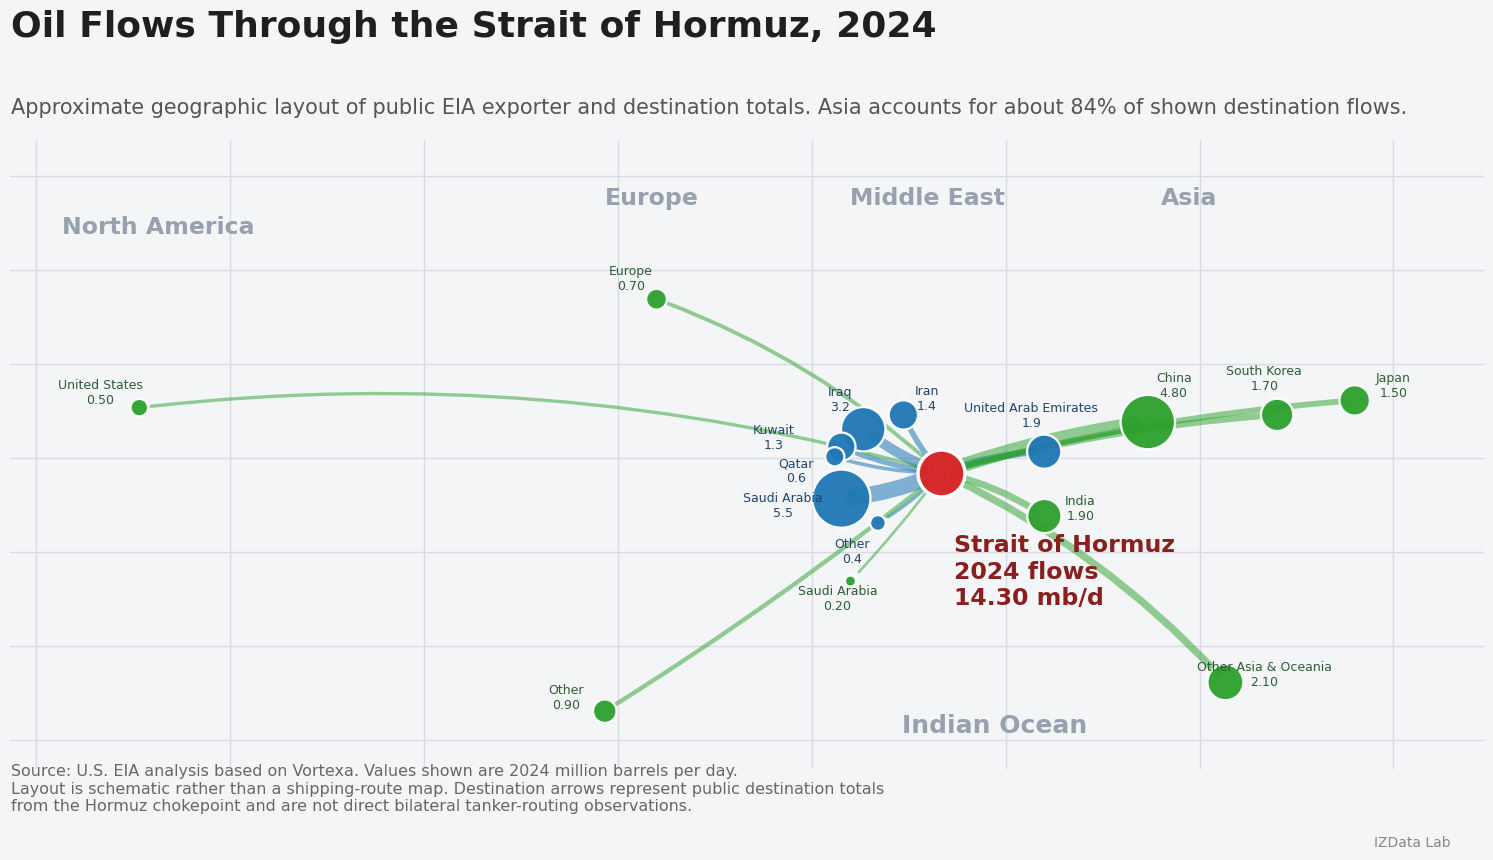

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# ============================================================
# Oil Flows Through the Strait of Hormuz, 2024
# Publication-style macro map (schematic)
# Labels are manually offset with NO label boxes
# Gulf exporters are automatically spread around Hormuz
# ============================================================

# -----------------------------
# 1. Input data (2024)
# -----------------------------
origins = {
    "Saudi Arabia": 5.5,
    "Iraq": 3.2,
    "United Arab Emirates": 1.9,
    "Iran": 1.4,
    "Kuwait": 1.3,
    "Qatar": 0.6,
    "Other": 0.4,
}

destinations = {
    "China": 4.8,
    "India": 1.9,
    "South Korea": 1.7,
    "Japan": 1.5,
    "Other Asia": 2.1,
    "Europe": 0.7,
    "United States": 0.5,
    "Saudi Arabia": 0.2,
    "Other": 0.9,
}

# -----------------------------
# 2. Build graph
# -----------------------------
G = nx.DiGraph()

hormuz_node = "Strait of Hormuz"
G.add_node(hormuz_node, node_type="chokepoint", volume=sum(origins.values()))

for country, flow in origins.items():
    G.add_node(country, node_type="origin", volume=flow)
    G.add_edge(country, hormuz_node, weight=flow)

for country, flow in destinations.items():
    node_name = f"{country} (dest)" if country in origins else country
    G.add_node(node_name, node_type="destination", volume=flow, label=country)
    G.add_edge(hormuz_node, node_name, weight=flow)

# -----------------------------
# 3. Manual positions
# -----------------------------
pos = {
    # Hormuz
    "Strait of Hormuz": (0.70, 0.39),

    # Destinations
    "United States": (0.08, 0.48),
    "Europe": (0.48, 0.63),
    "Saudi Arabia (dest)": (0.63, 0.24),
    "China": (0.86, 0.46),
    "India": (0.78, 0.33),
    "South Korea": (0.96, 0.47),
    "Japan": (1.02, 0.49),
    "Other Asia": (0.92, 0.10),
    "Other (dest)": (0.44, 0.06),
}

# -----------------------------
# 4. Automatically spread Gulf exporters
# -----------------------------
gulf_exporters = [
    "Iraq",
    "Iran",
    "United Arab Emirates",
    "Saudi Arabia",
    "Qatar",
    "Other",
    "Kuwait",
]

hx, hy = pos[hormuz_node]

radius = 0.085
angles_deg = [135, 110, 20, 205, 165, 235, 155]  # tweak these if desired

for node, angle in zip(gulf_exporters, angles_deg):
    rad = np.radians(angle)
    pos[node] = (
        hx + radius * np.cos(rad),
        hy + radius * np.sin(rad)
    )

# -----------------------------
# 5. Style settings
# -----------------------------
origin_color = "#1f77b4"
destination_color = "#2ca02c"
hormuz_color = "#d62728"
grid_color = "#d8dbe2"
bg_color = "#f4f5f7"
text_dark = "#1f1f1f"
text_muted = "#6b7280"
region_color = "#97a1af"

fig, ax = plt.subplots(figsize=(16, 9))
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

# -----------------------------
# 6. Background grid / map frame
# -----------------------------
for x in [0.0, 0.15, 0.30, 0.45, 0.60, 0.75, 0.90, 1.05, 1.15]:
    ax.plot([x, x], [-0.05, 0.85], color=grid_color, lw=1, zorder=0)

for y in [0.02, 0.15, 0.28, 0.41, 0.54, 0.67, 0.80]:
    ax.plot([-0.02, 1.15], [y, y], color=grid_color, lw=1, zorder=0)

ax.text(0.02, 0.72, "North America", fontsize=17, color=region_color, weight="bold")
ax.text(0.44, 0.76, "Europe", fontsize=17, color=region_color, weight="bold")
ax.text(0.63, 0.76, "Middle East", fontsize=17, color=region_color, weight="bold")
ax.text(0.87, 0.76, "Asia", fontsize=17, color=region_color, weight="bold")
ax.text(0.67, 0.03, "Indian Ocean", fontsize=18, color=region_color, weight="bold")

# -----------------------------
# 7. Draw edges
# -----------------------------
origin_edges = [(u, v) for u, v in G.edges() if v == hormuz_node]
dest_edges = [(u, v) for u, v in G.edges() if u == hormuz_node]

# Origin -> Hormuz
for u, v in origin_edges:
    flow = G[u][v]["weight"]
    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=[(u, v)],
        ax=ax,
        edge_color=origin_color,
        width=1.5 + flow * 1.8,
        alpha=0.55,
        arrows=True,
        arrowstyle="-",
        connectionstyle="arc3,rad=0.08",
    )

# Hormuz -> Destination
for u, v in dest_edges:
    flow = G[u][v]["weight"]

    rad = 0.0
    if v in ["United States", "Europe"]:
        rad = 0.10
    elif v in ["China", "South Korea", "Japan"]:
        rad = -0.05
    elif v in ["Other Asia", "India"]:
        rad = -0.10
    elif v in ["Other (dest)", "Saudi Arabia (dest)"]:
        rad = -0.03

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=[(u, v)],
        ax=ax,
        edge_color=destination_color,
        width=1.5 + flow * 1.8,
        alpha=0.50,
        arrows=True,
        arrowstyle="-",
        connectionstyle=f"arc3,rad={rad}",
    )

# -----------------------------
# 8. Draw nodes
# -----------------------------
origin_nodes = [n for n, d in G.nodes(data=True) if d["node_type"] == "origin"]
destination_nodes = [n for n, d in G.nodes(data=True) if d["node_type"] == "destination"]

origin_sizes = [origins[n] * 320 for n in origin_nodes]
destination_sizes = [G.nodes[n]["volume"] * 320 for n in destination_nodes]
hormuz_size = sum(origins.values()) * 80

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=origin_nodes,
    node_size=origin_sizes,
    node_color=origin_color,
    edgecolors="white",
    linewidths=1.7,
    alpha=0.95,
    ax=ax,
)

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=destination_nodes,
    node_size=destination_sizes,
    node_color=destination_color,
    edgecolors="white",
    linewidths=1.7,
    alpha=0.95,
    ax=ax,
)

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=[hormuz_node],
    node_size=hormuz_size,
    node_color=hormuz_color,
    edgecolors="white",
    linewidths=2.5,
    alpha=0.98,
    ax=ax,
)

# -----------------------------
# 9. Manual label offsets
#    Edit these numbers to fine-tune label placement
#    (dx, dy): +x = right, -x = left, +y = up, -y = down
# -----------------------------
label_offsets = {
    # exporters
    "Saudi Arabia": (-0.045, -0.010),
    "Iraq": (-0.018, 0.040),
    "United Arab Emirates": (-0.010, 0.05),
    "Iran": (0.018, 0.022),
    "Kuwait": (-0.052, 0.012),
    "Qatar": (-0.030, -0.020),
    "Other": (-0.020, -0.040),

    # destinations
    "China": (0.020, 0.050),
    "India": (0.028, 0.010),
    "South Korea": (-0.010, 0.050),
    "Japan": (0.030, 0.020),
    "Other Asia": (0.030, 0.010),
    "Europe": (-0.020, 0.028),
    "United States": (-0.030, 0.020),
    "Saudi Arabia (dest)": (-0.010, - 0.025),
    "Other (dest)": (-0.030, 0.018),
}

# -----------------------------
# 10. Draw labels WITHOUT boxes
# -----------------------------
for n in origin_nodes:
    x, y = pos[n]
    dx, dy = label_offsets.get(n, (0.01, 0.01))
    val = origins[n]

    ax.text(
        x + dx,
        y + dy,
        f"{n}\n{val:.1f}",
        fontsize=9,
        ha="center",
        va="center",
        color="#24456b",
        zorder=10,
    )

for n in destination_nodes:
    x, y = pos[n]
    dx, dy = label_offsets.get(n, (0.01, 0.01))
    label = G.nodes[n].get("label", n)
    val = G.nodes[n]["volume"]

    if label == "Other Asia":
        label = "Other Asia & Oceania"

    ax.text(
        x + dx,
        y + dy,
        f"{label}\n{val:.2f}",
        fontsize=9,
        ha="center",
        va="center",
        color="#2e5d35",
        zorder=10,
    )

# Hormuz label: bottom-right of red node
ax.text(
    hx + 0.01,
    hy - 0.085,
    "Strait of Hormuz\n2024 flows\n14.30 mb/d",
    fontsize=17,
    weight="bold",
    color="#8b1e1e",
    ha="left",
    va="top",
    zorder=10,
)

# -----------------------------
# 11. Titles and footnotes
# -----------------------------
asia_share = (
    destinations["China"]
    + destinations["India"]
    + destinations["South Korea"]
    + destinations["Japan"]
    + destinations["Other Asia"]
) / sum(destinations.values())

fig.text(
    0.05,
    0.93,
    "Oil Flows Through the Strait of Hormuz, 2024",
    fontsize=26,
    weight="bold",
    color=text_dark,
)

fig.text(
    0.05,
    0.845,
    f"Approximate geographic layout of public EIA exporter and destination totals. "
    f"Asia accounts for about {asia_share:.0%} of shown destination flows.",
    fontsize=15,
    color="#555555",
)

fig.text(
    0.05,
    0.07,
    "Source: U.S. EIA analysis based on Vortexa. Values shown are 2024 million barrels per day.\n"
    "Layout is schematic rather than a shipping-route map. Destination arrows represent public destination totals\n"
    "from the Hormuz chokepoint and are not direct bilateral tanker-routing observations.",
    fontsize=11.5,
    color="#666666",
)

fig.text(
    0.95, 0.03,
    "IZData Lab",
    fontsize=10,
    color="#888888",
    ha="right"
)

# -----------------------------
# 12. Final formatting
# -----------------------------
ax.set_xlim(-0.02, 1.12)
ax.set_ylim(-0.02, 0.86)
ax.axis("off")

plt.tight_layout(rect=[0.04, 0.10, 0.98, 0.84])
plt.savefig("Oil_Flows_Thorugh_the_Strait_of_Hormuz.png", dpi=300, bbox_inches="tight")
plt.show()

### SOURCE: https://www.eia.gov/todayinenergy/detail.php?id=65504